In [2]:
import sys
from pathlib import Path

# Adicionar a raiz do projeto ao Python path para importar src/
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.load_data import load_raw_data, get_data_info
from src.features.build_features import build_features, get_feature_groups

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Carregar usando o módulo 
df_raw = load_raw_data()
info = get_data_info(df_raw)

print(" Informação do dataset bruto: ")
for k, v in info.items():
    print(f" {k}: {v}")

 Informação do dataset bruto: 
 shape: (284807, 31)
 n_features: 30
 n_samples: 284807
 missing_values: 0
 n_fraud: 492
 n_legit: 284315
 fraud_rate_pct: 0.1727
 imbalance_ratio: 577.9


In [4]:
# Aplicar pipeline de features 
df_features = build_features(df_raw)

print(f" Shape antes: {df_raw.shape}")
print(f" Shape depois: {df_features.shape}")

print(f"\n Features criadas: {set(df_features.columns) - set(df_raw.columns)}")
print(f"\n Primeiras linhas das novas features:")
df_features[['Time', 'Hour', 'Hour_sin', 'Hour_cos', 'Amount', 'Amount_log', 'is_amount_zero']].head()

 Shape antes: (284807, 31)
 Shape depois: (284807, 36)

 Features criadas: {'Hour_cos', 'is_amount_zero', 'Hour', 'Amount_log', 'Hour_sin'}

 Primeiras linhas das novas features:


,Time,Hour,Hour_sin,Hour_cos,Amount,Amount_log,is_amount_zero
0,0.0,0.000000,0.000000,1.0,149.62,5.014760,0
1,0.0,0.000000,0.000000,1.0,2.69,1.305626,0
2,1.0,0.000278,0.000073,1.0,378.66,5.939276,0
3,1.0,0.000278,0.000073,1.0,123.50,4.824306,0
4,2.0,0.000556,0.000145,1.0,69.99,4.262539,0


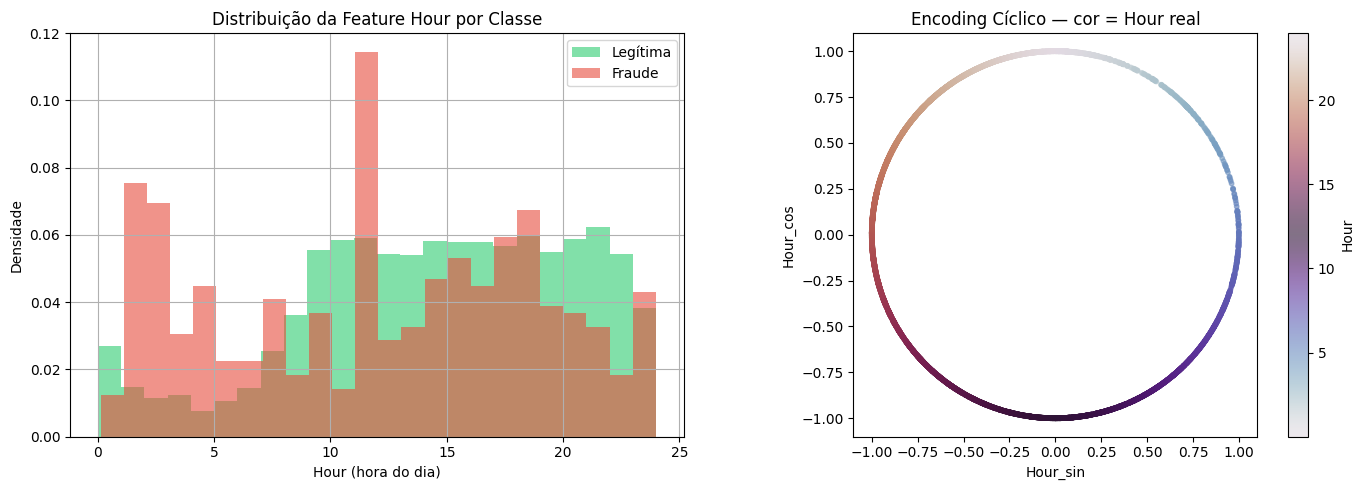

In [5]:
# Visualizar distribuição da feature Hour por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Hour por classe
for class_val, color, label in [(0, '#2ecc71', 'Legítima'), (1, '#e74c3c', 'Fraude')]:
    df_features[df_features['Class'] == class_val]['Hour'].hist(
        bins=24, ax=axes[0], alpha=0.6, color=color, label=label, density=True
    )
axes[0].set_xlabel('Hour (hora do dia)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição da Feature Hour por Classe')
axes[0].legend()

# Subplot 2: Encoding cíclico (Hour_sin × Hour_cos = círculo)
sample = df_features.sample(5000, random_state=RANDOM_STATE)
axes[1].scatter(sample['Hour_sin'], sample['Hour_cos'], 
                c=sample['Hour'], cmap='twilight', s=10, alpha=0.6)
axes[1].set_xlabel('Hour_sin')
axes[1].set_ylabel('Hour_cos')
axes[1].set_title('Encoding Cíclico — cor = Hour real')
axes[1].set_aspect('equal')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Hour')

plt.tight_layout()
plt.show()

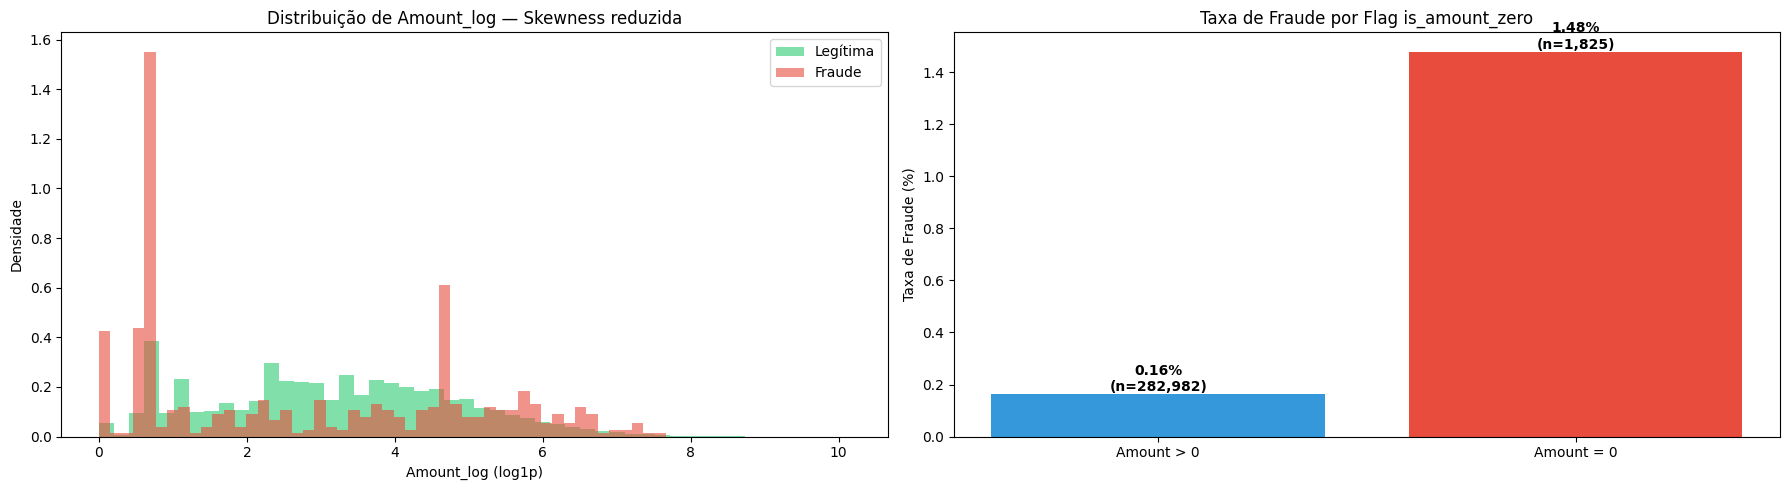

In [6]:
# Validação das features de Amount
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Subplot 1: Amount original vs Amount_log
axes[0].hist(df_features[df_features['Class'] == 0]['Amount_log'], bins=50, 
             alpha=0.6, color='#2ecc71', label='Legítima', density=True)
axes[0].hist(df_features[df_features['Class'] == 1]['Amount_log'], bins=50,
             alpha=0.6, color='#e74c3c', label='Fraude', density=True)
axes[0].set_xlabel('Amount_log (log1p)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Amount_log — Skewness reduzida')
axes[0].legend()

# Subplot 2: is_amount_zero — taxa de fraude
zero_stats = df_features.groupby('is_amount_zero')['Class'].agg(['mean', 'count'])
zero_stats['fraud_pct'] = zero_stats['mean'] * 100
axes[1].bar(['Amount > 0', 'Amount = 0'], zero_stats['fraud_pct'].values,
            color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Taxa de Fraude (%)')
axes[1].set_title('Taxa de Fraude por Flag is_amount_zero')

# Anotar valores
for i, (count, pct) in enumerate(zip(zero_stats['count'].values, zero_stats['fraud_pct'].values)):
    axes[1].text(i, pct, f'{pct:.2f}%\n(n={count:,})', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
print("\n Validação numérica:")
print(f"   Skewness Amount original: {df_features['Amount'].skew():.2f}")
print(f"   Skewness Amount_log: {df_features['Amount_log'].skew():.2f}")
print(f"\n   Taxa de fraude com Amount=0: {zero_stats.loc[1, 'fraud_pct']:.3f}%")
print(f"   Taxa de fraude com Amount>0: {zero_stats.loc[0, 'fraud_pct']:.3f}%")
print(f"   Razão: {zero_stats.loc[1, 'fraud_pct'] / zero_stats.loc[0, 'fraud_pct']:.1f}x")


 Validação numérica:
   Skewness Amount original: 16.98
   Skewness Amount_log: 0.16

   Taxa de fraude com Amount=0: 1.479%
   Taxa de fraude com Amount>0: 0.164%
   Razão: 9.0x


In [8]:
from src.data.load_data import DATA_PROCESSED_PATH

# Garantir que pasta existe
DATA_PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# Salvar em formato parquet (mais rápido e menor que CSV)
output_path = DATA_PROCESSED_PATH / "creditcard_features.parquet"
df_features.to_parquet(output_path, index=False)

# Validar tamanhos
import os
size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f" Dataset salvo em: {output_path}")
print(f" Tamanho: {size_mb:.2f} MB")
print(f" Shape: {df_features.shape}")
print(f" Total de features: {df_features.shape[1] - 1} (target excluído)")

 Dataset salvo em: C:\Users\flord\fraud-detection-ml\data\processed\creditcard_features.parquet
 Tamanho: 73.27 MB
 Shape: (284807, 36)
 Total de features: 35 (target excluído)
